# Sentinel Brain — prototype des 4 couches (tâche j3)

**Objectif** : détecter une anomalie *avant* qu'un seuil fixe ne se déclenche, l'expliquer en une phrase et prévoir
dans combien de minutes la situation devient critique, sans fausse alarme en régime normal.

**Fini quand** (tasks.yml) : *sur les scénarios simulés, le score monte et `eta_min` est calculé avant tout seuil brut.*

```
 MQTT (journal de réception)                                                     sorties
 ─────────────────────────┐                                                    ┌──────────────────────────────
 telemetry / event /      │  Couche 1  qualité, intégrité  ── rejet ──► cyber  │ sentinel/brain/score (2 s)
 health / status          ├─►Couche 2  niveau (CUSUM) + vitesse de montée ─┐   │ POST /api/v1/alerts
                          │  Couche 3  Isolation Forest (fenêtres 60 s) ───┼─► │   type, gravité, score,
                          │  Couche 4  prévision de Holt -> eta_min ───────┘   │   eta_min, explication,
                          └─ fusion : environnement / physique / cyber + règles│   facteurs
```

Le code n'est **pas** dans ce notebook : il est dans le paquet `ai/anomaly/brain/` (le même code tournera dans le
conteneur `anomaly` du PC serveur). Le notebook rejoue des données, calibre, mesure et trace.

Lancement (depuis la racine du dépôt, `.venv` activé) : `jupyter lab ai/anomaly/notebooks/01-prototype.ipynb`,
puis *Run All*. Les jeux de données sont régénérés automatiquement s'ils manquent (simulateur, graines fixes).

In [1]:
import json
import math
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tools" / "simulator.py").exists())
ANOM = ROOT / "ai" / "anomaly"
DATA = ANOM / "data"
sys.path.insert(0, str(ANOM))
from brain import BrainConfig, SentinelBrain
from brain.config import CALIBRATION
from brain.detectors import Holt, RobustCusum

T0 = 1_790_000_000          # horloge de départ du simulateur quand une graine est fixée
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3, "font.size": 9})

def simulate(name, *args):
    # Régénère un jeu de données s'il manque (reproductible : graine et horloge fixes).
    if not (DATA / f"{name}_rx.jsonl").exists():
        DATA.mkdir(parents=True, exist_ok=True)
        cmd = [sys.executable, str(ROOT / "tools" / "simulator.py"), "--no-mqtt", "--speed", "100000",
               "--csv", str(DATA / f"{name}.csv"), "--rx-log", str(DATA / f"{name}_rx.jsonl"), *args]
        subprocess.run(cmd, check=True, capture_output=True)
        print("généré :", name)

simulate("simu", "--scenario", "all", "--cooldown", "600", "--seed", "42")                # jeu d'évaluation
simulate("normal_24h", "--scenario", "normal", "--duration", "86400", "--seed", "7")      # jeu de calibration
print("racine :", ROOT)

racine : /home/claude/sx


## 1. Les données : deux vues du même boîtier simulé

Le simulateur (tâche j1) produit deux fichiers :

| Fichier | Vue | Usage |
| --- | --- | --- |
| `simu.csv` | **capteurs** : chaque mesure prise, avec l'étiquette du scénario | vérité terrain pour l'évaluation |
| `simu_rx.jsonl` | **réseau** : tout ce que le broker reçoit, dans l'ordre d'arrivée (télémétrie, événements, santé, statut, rejeux, tampon renvoyé après coupure) | **entrée de Brain** |

Brain ne voit jamais les étiquettes : il apprend seul. Deux jeux **différents** : la calibration se fait sur 24 h de régime
normal (graine 7), l'évaluation sur un autre tirage avec les 7 scénarios (graine 42) et sur 24 h normales jamais vues.

In [2]:
cap = pd.read_csv(DATA / "simu.csv")
rx = [json.loads(ln) for ln in open(DATA / "simu_rx.jsonl", encoding="utf-8")]
cap["t"] = cap.ts - T0
blk = (cap.label != cap.label.shift()).cumsum()
plan = cap.groupby(blk).agg(etiquette=("label", "first"), debut_s=("t", "min"), fin_s=("t", "max"),
                            mesures=("seq", "count"), gaz_max=("gas_ratio", "max"), temp_max=("temp_c", "max"))
SCEN = ["drift", "gas_leak", "fire", "intrusion", "tamper", "replay", "jamming"]
START = {s: int(cap.t[cap.label == s].min()) for s in SCEN}
END = {s: int(cap.t[cap.label == s].max()) for s in SCEN}

kinds = pd.Series([m["topic"].split("/")[-1] + ("" if m["topic"].endswith(("health", "status")) or
                   not isinstance(m["payload"], dict) else
                   (":" + m["payload"]["type"] if "type" in m["payload"] else
                    (":replay=true" if m["payload"].get("replay") else ""))) for m in rx]).value_counts()
display(plan[plan.etiquette != "normal"].reset_index(drop=True))
print(f"{len(cap)} mesures capteurs, {len(rx)} messages reçus par le broker, durée {cap.t.max()/3600:.1f} h")
display(kinds.to_frame("messages"))

,etiquette,debut_s,fin_s,mesures,gaz_max,temp_max
0,drift,900,1198,150,1.022,25.0
1,drift_recovery,1200,1798,300,1.073,25.0
2,gas_leak,2700,2999,474,1.996,23.0
3,gas_leak_recovery,3000,3598,658,1.991,22.0
4,fire,4500,4799,479,1.849,31.0
5,fire_recovery,4800,5398,604,1.822,31.0
6,intrusion,6300,6598,150,1.073,23.0
7,intrusion_recovery,6600,7198,300,1.063,23.0
8,tamper,8100,8398,150,1.034,22.0
9,tamper_recovery,8400,8998,300,1.063,22.0


8065 mesures capteurs, 8732 messages reçus par le broker, durée 3.7 h


,messages
telemetry,7955
health,443
event:pir,206
telemetry:replay=true,120
event:gas_do,3
status,2
event:boot,1
event:mode_change,1
event:tamper,1


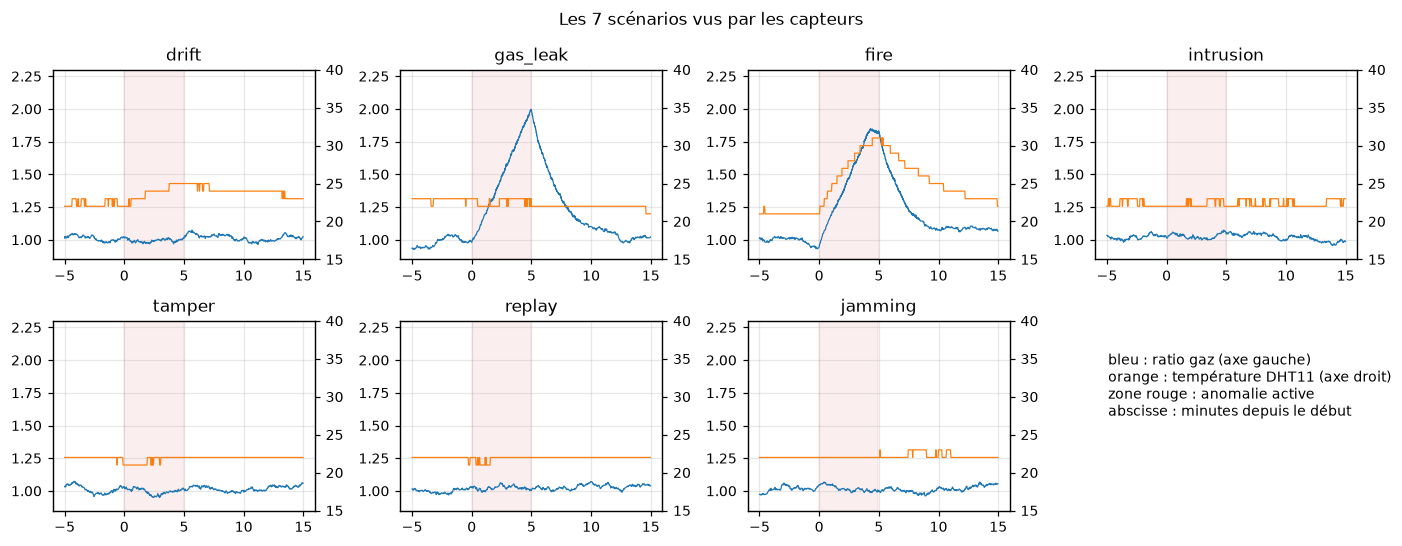

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharey=False)
for ax, s in zip(axes.flat, SCEN, strict=False):
    w = cap[(cap.t >= START[s] - 300) & (cap.t <= END[s] + 600)]
    ax.plot((w.t - START[s]) / 60, w.gas_ratio, lw=.8, label="ratio gaz")
    ax.axvspan(0, (END[s] - START[s]) / 60, color="tab:red", alpha=.08)
    ax.set_title(s); ax.set_ylim(.85, 2.3)
    ax2 = ax.twinx(); ax2.plot((w.t - START[s]) / 60, w.temp_c, color="tab:orange", lw=.8); ax2.set_ylim(15, 40)
    ax2.grid(False)
axes.flat[-1].axis("off")
axes.flat[-1].text(.05, .5, "bleu : ratio gaz (axe gauche)\norange : température DHT11 (axe droit)\n"
                   "zone rouge : anomalie active\nabscisse : minutes depuis le début", fontsize=9)
fig.suptitle("Les 7 scénarios vus par les capteurs"); fig.tight_layout()

## 2. Pourquoi un seuil fixe ne suffit pas — et pourquoi un CUSUM naïf non plus

Un seuil fixe (ratio gaz 1,3 / température 35 °C, profil de site) réagit **tard** : la fuite est déjà là.
Abaisser le seuil ? Le MQ-2 « respire » naturellement de ±3 % à ±10 %, et surtout **lentement** : ses écarts durent
plus d'une minute (autocorrélation ci-dessous). Un CUSUM appliqué mesure par mesure prend ces lentes respirations
pour des dérives : nos premiers essais donnaient **plus de 5 fausses alarmes par heure**.

Deux réponses, classiques en maîtrise statistique des procédés :

1. **CUSUM décorrélé** : on ne compte qu'une observation indépendante par `tau_d` secondes (`w = dt / tau_d`).
   Cela rend aussi le détecteur insensible au rythme d'envoi (rafales à 500 ms du firmware).
2. **Vitesse de montée** : une fuite ou un feu se distinguent d'abord par leur *vitesse* (comme les détecteurs
   thermovélocimétriques de l'incendie). La tendance de Holt est comparée à la plus forte montée vue en régime sain.

gaz en régime normal : écart-type 0.026, min 0.89, max 1.10, autocorrélation à 60 s = 0.58


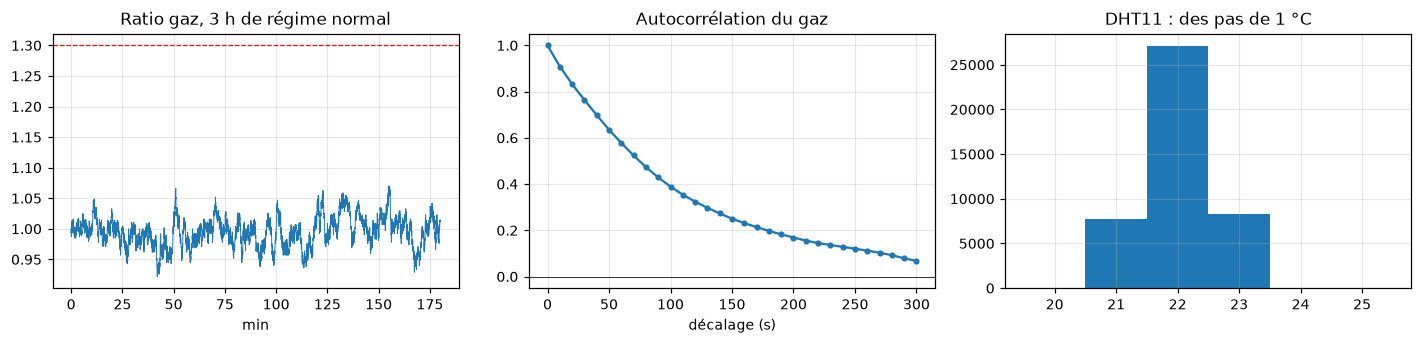

In [4]:
nor = pd.read_csv(DATA / "normal_24h.csv"); nor["t"] = nor.ts - nor.ts.iloc[0]
g = nor.gas_ratio.to_numpy()
lags = np.arange(0, 151, 5)                       # en mesures de 2 s
acf = [1.0] + [np.corrcoef(g[:-k], g[k:])[0, 1] for k in lags[1:]]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].plot(nor.t[:5400] / 60, nor.gas_ratio[:5400], lw=.6); ax[0].axhline(1.3, color="r", ls="--", lw=.8)
ax[0].set_title("Ratio gaz, 3 h de régime normal"); ax[0].set_xlabel("min")
ax[1].plot(lags * 2, acf, marker="o", ms=3); ax[1].axhline(0, color="k", lw=.5)
ax[1].set_title("Autocorrélation du gaz"); ax[1].set_xlabel("décalage (s)")
ax[2].hist(nor.temp_c, bins=np.arange(19.5, 26.5, 1)); ax[2].set_title("DHT11 : des pas de 1 °C")
fig.tight_layout()
print(f"gaz en régime normal : écart-type {g.std():.3f}, min {g.min():.2f}, max {g.max():.2f}, "
      f"autocorrélation à 60 s = {acf[6]:.2f}")

## 3. Calibration (sur le jeu normal de 24 h uniquement)

On cherche, pour chaque capteur, le réglage le plus **rapide** qui ne donne **aucune** fausse alarme sur 24 h normales.
La cellule suivante refait la recherche pour le CUSUM de niveau du gaz (les autres capteurs se calibrent avec la même
fonction ; les valeurs retenues sont dans `brain/config.py`, dictionnaire `CALIBRATION`). Le délai de détection est
mesuré sur le jeu d'évaluation, pour information : ce n'est pas lui qui choisit.

> **À refaire sur données réelles** (tâche « Données réelles ») : remplacer `normal_24h` par quelques heures
> enregistrées avec `mosquitto_sub -v -t 'sentinel/#'`, relancer cette section, reporter les valeurs dans `CALIBRATION`.

In [5]:
def alarm_starts(ts, x, det):
    # Instants où le détecteur passe en alarme (début d'épisode).
    out, prev = [], False
    for t, v in zip(ts, x, strict=True):
        a = det.update(float(v), float(t)).alarm
        if a and not prev:
            out.append(t)
        prev = a
    return out

def first_after(starts, t0, t1):
    d = [s - t0 for s in starts if t0 - 5 <= s <= t1]
    return int(d[0]) if d else None

hours = (nor.t.iloc[-1] - 600) / 3600
rows = []
t_start = time.time()
for k in (1.0, 1.5, 2.0):
    for h in (4.0, 6.0, 8.0):
        kw = dict(k=k, h=h, tau_d=60.0, min_sigma=0.02, direction="up")
        fp = len(alarm_starts(nor.t, nor.gas_ratio, RobustCusum("gaz", **kw)))
        ev = alarm_starts(cap.t, cap.gas_ratio, RobustCusum("gaz", **kw))
        rows.append({"k": k, "h": h, "fausses alarmes / 24 h": round(fp / hours * 24, 1),
                     "délai fuite (s)": first_after(ev, START["gas_leak"], END["gas_leak"]),
                     "délai feu (s)": first_after(ev, START["fire"], END["fire"])})
calib = pd.DataFrame(rows)
display(calib.style.highlight_between(subset=["fausses alarmes / 24 h"], left=0, right=0, color="#d4f4dd"))
print(f"({time.time() - t_start:.0f} s de calcul)")

,k,h,fausses alarmes / 24 h,délai fuite (s),délai feu (s)
0,1.000000,4.000000,3.000000,82,74
1,1.000000,6.000000,1.000000,96,87
2,1.000000,8.000000,0.000000,108,99
3,1.500000,4.000000,0.000000,86,78
4,1.500000,6.000000,0.000000,100,95
5,1.500000,8.000000,0.000000,113,114
6,2.000000,4.000000,0.000000,90,78
7,2.000000,6.000000,0.000000,105,97
8,2.000000,8.000000,0.000000,118,115


(28 s de calcul)


Le CUSUM de niveau seul, réglé sans fausse alarme, détecte la fuite à peu près **en même temps que le seuil brut**
(≈ 95 s) : sur un signal qui respire autant, le niveau seul ne fait pas gagner de temps. D'où le second canal,
la **vitesse de montée**, calibré ci-dessous : plus forte montée observée en 24 h saines, × 1,25 de marge.

In [6]:
def holt_rates(df, col, tau_trend, scale, smooth):
    h, out, s, lt = Holt(tau_level=20.0 if smooth else 10.0, tau_trend=tau_trend), [], None, None
    for t, v in zip(df.t, df[col], strict=True):
        if smooth:          # même lissage du DHT11 que dans Brain
            s = v if s is None else s + (1 - math.exp(-max(0, t - lt) / 20.0)) * (v - s); lt = t; v = s
        h.update(float(v), float(t)); out.append(h.trend * 60 * scale)
    return np.array(out)

env = []
for col, unit, scale, smooth in (("gas_ratio", "%/min", 100, False), ("temp_c", "°C/min", 1, True)):
    cfg = CALIBRATION[col]
    r = holt_rates(nor, col, cfg["tau_trend"], scale, smooth)[300:]       # après l'apprentissage
    env.append({"capteur": col, "unité": unit, "montée saine max": round(r.max(), 2),
                "× 1,25": round(1.25 * r.max(), 2), "plancher retenu": cfg["rate_floor"]})
display(pd.DataFrame(env))
pd.DataFrame(CALIBRATION).T

,capteur,unité,montée saine max,"× 1,25",plancher retenu
0,gas_ratio,%/min,8.21,10.27,10.00
1,temp_c,°C/min,0.59,0.74,0.75


,k,h,tau_d,min_sigma,rate_floor,tau_trend
gas_ratio,1.5,6.0,60.0,0.02,10.00,30.0
temp_c,1.5,5.0,60.0,0.50,0.75,60.0
hum_pct,2.0,5.0,30.0,1.00,NaN,NaN
rssi,2.0,3.0,30.0,2.00,NaN,NaN


## 4. Rejeu complet dans Sentinel Brain

On rejoue le journal réseau message par message, exactement comme le fera le service MQTT. On garde au passage les
valeurs internes des détecteurs pour les tracer.

In [7]:
brain = SentinelBrain(BrainConfig())
trace, alerts = [], []
t_start = time.perf_counter()
for m in rx:
    outs = brain.handle(m["topic"], m["payload"], m["rx_ts"])
    d = brain.devices.get("esp-01")
    for o in outs:
        if o["kind"] == "alert":
            alerts.append({**o["payload"], "rx_t": m["rx_ts"] - T0, "scénario": m["label"]})
        else:
            p = o["payload"]
            trace.append({"t": p["ts"] - T0, "label": m["label"], **{k: p[k] for k in
                          ("score", "environment", "physical", "cyber", "eta_min")}, **p["layers"],
                          "eta_gas": p["eta_by"].get("gas_ratio"),
                          "gas": m["payload"]["gas_ratio"], "temp": m["payload"]["temp_c"],
                          "gas_base": d.c_gas.mu, "gas_sigma": d.c_gas.sigma, "S_gas": d.c_gas.s_up / d.c_gas.h,
                          "rate_gas": d.r_gas.rate, "rate_gas_thr": d.r_gas.threshold,
                          "temp_s": d.temp_s, "temp_base": d.c_temp.mu, "S_temp": d.c_temp.s_up / d.c_temp.h,
                          "rate_temp": d.r_temp.rate, "rate_temp_thr": d.r_temp.threshold})
elapsed = time.perf_counter() - t_start
tr = pd.DataFrame(trace)
al = pd.DataFrame(alerts)
al["t"] = al.ts - T0
print(f"{len(rx)} messages en {elapsed:.1f} s, soit {1000 * elapsed / len(rx):.2f} ms par message "
      f"(le boîtier en envoie 0,5 par seconde) ; modèles Isolation Forest entraînés : {brain.devices['esp-01'].mv.fits}")
al[["t", "scénario", "type", "severity", "score", "eta_min", "explanation"]]

8732 messages en 10.9 s, soit 1.25 ms par message (le boîtier en envoie 0,5 par seconde) ; modèles Isolation Forest entraînés : 5


,t,scénario,type,severity,score,eta_min,explanation
0,1168,drift,thermal_drift,warning,60,NaN,"Température en dérive : 24,9 °C (lissée) contr..."
1,2736,gas_leak,gas_leak,warning,71,7.3,Gaz +7 % au-dessus de la ligne de base (ratio ...
2,2776,gas_leak,gas_leak,critical,100,3.0,Gaz +21 % au-dessus de la ligne de base (ratio...
3,4520,fire,gas_leak,warning,71,7.2,Gaz +5 % au-dessus de la ligne de base (ratio ...
4,4550,fire,fire_risk,critical,100,3.1,"Gaz +15 % et température en hausse (24 °C, 1,0..."
5,6312,intrusion,intrusion_suspected,warning,70,NaN,"4 détections PIR en une minute contre 0,2 habi..."
6,8100,tamper,sabotage,critical,100,NaN,Ouverture ou manipulation du boîtier (capteur ...
7,9900,replay,cyber_attack,critical,100,NaN,Message rejeté par le contrôle d'intégrité : s...
8,11730,jamming,jamming_suspected,warning,60,NaN,Signal Wi-Fi en chute (RSSI -72 dBm contre -55...
9,11760,jamming,jamming_suspected,critical,80,NaN,Signal Wi-Fi en chute (RSSI -75 dBm contre -55...


## 5. Couche 2 sur la fuite de gaz : le niveau et la vitesse

Haut : la mesure, la ligne de base apprise (gelée pendant la suspicion pour ne pas « apprendre la fuite ») et les seuils
fixes du profil de site. Milieu : les deux canaux de la couche 2, normalisés (1 = seuil de décision). Bas : le score
environnement et la prévision.

Première alerte : Gaz +7 % au-dessus de la ligne de base (ratio 1,07), montée de +10 %/min (maximum sain 10 %/min), température stable (22 °C) ; ratio gaz critique (1,8) prévu dans 7,3 min


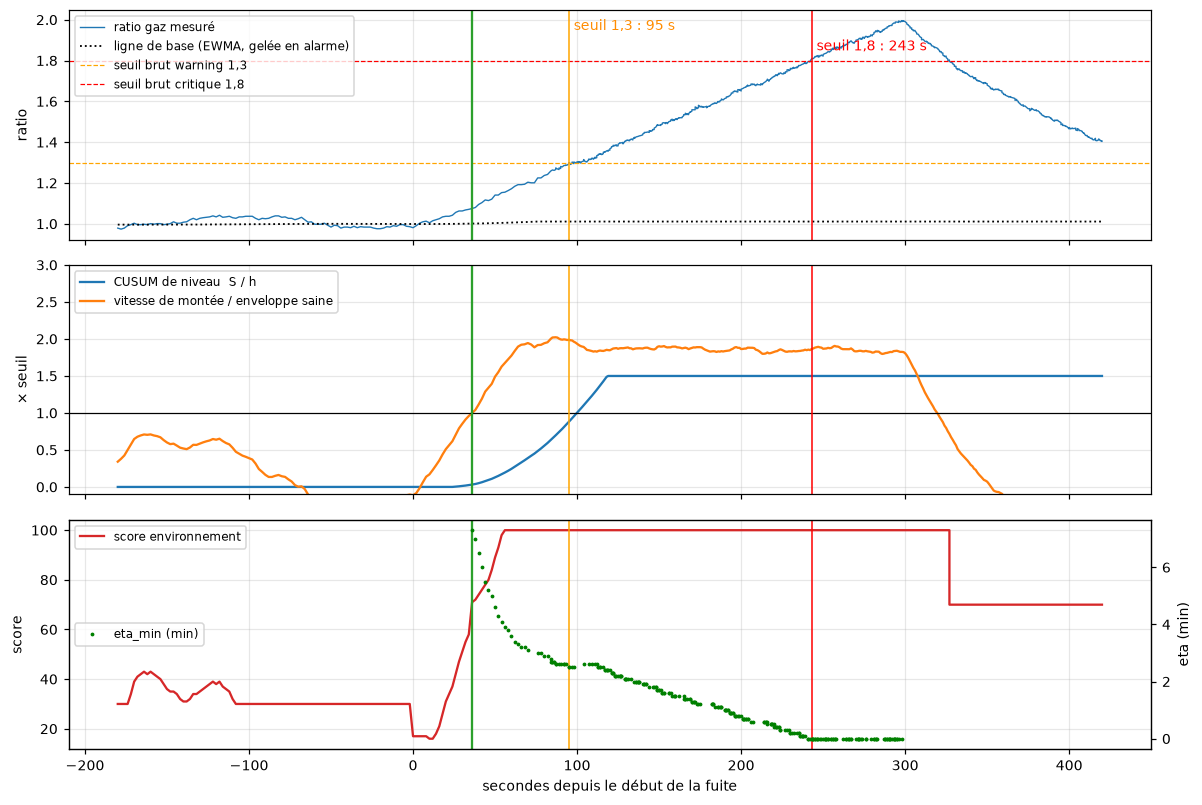

In [8]:
def zoom(s, before=180, after=420):
    return tr[(tr.t >= START[s] - before) & (tr.t <= START[s] + after)].assign(x=lambda w: w.t - START[s])

def raw_cross(s, col, thr):
    # premier franchissement d'un seuil brut pendant l'anomalie ou son retour au calme (10 min)
    w = cap[(cap.t >= START[s]) & (cap.t <= END[s] + 600) & (cap[col] >= thr)]
    return int(w.t.iloc[0] - START[s]) if len(w) else None

def first_alert(s, types):
    a = al[al.type.isin(types) & (al.t >= START[s] - 5) & (al.t <= END[s] + 600)]
    return (int(a.t.iloc[0] - START[s]), a.iloc[0]) if len(a) else (None, None)

w = zoom("gas_leak")
det, a0 = first_alert("gas_leak", ["gas_leak", "fire_risk"])
r13, r18 = raw_cross("gas_leak", "gas_ratio", 1.3), raw_cross("gas_leak", "gas_ratio", 1.8)
fig, ax = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
ax[0].plot(w.x, w.gas, lw=.9, label="ratio gaz mesuré")
ax[0].plot(w.x, w.gas_base, lw=1.2, color="k", ls=":", label="ligne de base (EWMA, gelée en alarme)")
for thr, c, lab in ((1.3, "orange", "seuil brut warning 1,3"), (1.8, "red", "seuil brut critique 1,8")):
    ax[0].axhline(thr, color=c, ls="--", lw=.8, label=lab)
ax[0].set_ylabel("ratio"); ax[0].legend(loc="upper left", fontsize=8)
ax[1].plot(w.x, w.S_gas, label="CUSUM de niveau  S / h"); ax[1].plot(w.x, w.rate_gas / w.rate_gas_thr,
           label="vitesse de montée / enveloppe saine"); ax[1].axhline(1, color="k", lw=.8)
ax[1].set_ylim(-.1, 3); ax[1].legend(loc="upper left", fontsize=8); ax[1].set_ylabel("× seuil")
ax[2].plot(w.x, w.environment, color="tab:red", label="score environnement")
ax2 = ax[2].twinx(); ax2.plot(w.x, w.eta_min, "g.", ms=3, label="eta_min (min)"); ax2.set_ylabel("eta (min)")
ax2.grid(False); ax[2].set_ylabel("score"); ax[2].legend(loc="upper left", fontsize=8); ax2.legend(loc="center left", fontsize=8)
for a in ax:
    a.axvline(det, color="tab:green", lw=1.5); a.axvline(r13, color="orange", lw=1); a.axvline(r18, color="red", lw=1)
ax[0].annotate(f"Brain : {det} s", (det, 2.05), color="tab:green", fontsize=9)
ax[0].annotate(f"seuil 1,3 : {r13} s", (r13 + 3, 1.95), color="darkorange", fontsize=9)
ax[0].annotate(f"seuil 1,8 : {r18} s", (r18 + 3, 1.85), color="red", fontsize=9)
ax[2].set_xlabel("secondes depuis le début de la fuite"); fig.tight_layout()
print("Première alerte :", a0.explanation)

## 6. Couche 4 : la prévision tient-elle ?

À chaque mesure en alarme, Holt donne `eta_min` : *le seuil critique sera atteint dans X min si la tendance se
maintient*. On compare l'instant prévu (`t + eta`) à l'instant réel. On vérifie aussi notre Holt « en flux » (pas de temps
variable, coût constant, léger) contre l'implémentation de référence de `statsmodels`.

gas_leak  : première prévision à 36 s, erreur médiane +8 s, erreur sur les 60 premières secondes de prévision +13 s
fire      : première prévision à 20 s, erreur médiane +12 s, erreur sur les 60 premières secondes de prévision +15 s
au moment de l'alerte (36 s) : eta Brain = 7.3 min, eta statsmodels = 5.5 min, réel = 3.5 min


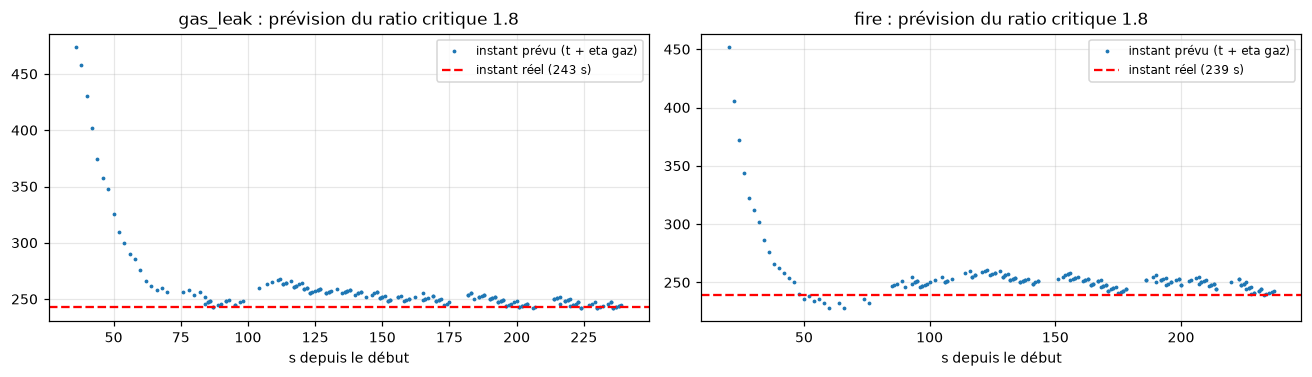

In [9]:
from statsmodels.tsa.holtwinters import Holt as SmHolt

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for i, (s, thr) in enumerate((("gas_leak", 1.8), ("fire", 1.8))):
    w = zoom(s, 0, 420).dropna(subset=["eta_gas"])
    w = w[w.eta_gas > 0]
    real = raw_cross(s, "gas_ratio", thr)
    ax[i].plot(w.x, w.x + 60 * w.eta_gas, ".", ms=3, label="instant prévu (t + eta gaz)")
    ax[i].axhline(real, color="r", ls="--", label=f"instant réel ({real} s)")
    ax[i].set_title(f"{s} : prévision du ratio critique {thr}"); ax[i].set_xlabel("s depuis le début")
    ax[i].legend(fontsize=8)
    err = (w.x + 60 * w.eta_gas - real)
    print(f"{s:9s} : première prévision à {int(w.x.iloc[0])} s, erreur médiane {err.median():+.0f} s, "
          f"erreur sur les 60 premières secondes de prévision {err[w.x < w.x.iloc[0] + 60].median():+.0f} s")
fig.tight_layout()

# contrôle croisé avec statsmodels, sur la série rééchantillonnée à 2 s, au moment de la première alerte de fuite
w = cap[(cap.t >= START["gas_leak"] - 120) & (cap.t <= START["gas_leak"] + det)].set_index("t").gas_ratio
y = w.groupby((w.index // 2) * 2).mean()
fit = SmHolt(y.to_numpy()).fit()
f = fit.forecast(600)
sm_eta = (np.argmax(f >= 1.8) + 1) * 2 / 60 if (f >= 1.8).any() else None
print(f"au moment de l'alerte ({det} s) : eta Brain = {a0.eta_min} min, eta statsmodels = "
      f"{sm_eta if sm_eta is None else round(sm_eta, 1)} min, réel = {(r18 - det) / 60:.1f} min")

## 7. Couche 1 : intégrité — rejeu malveillant et coupure Wi-Fi

Chaque message porte `boot_id` + `seq`. Un `seq` déjà vu pour ce `boot_id` est un **rejeu** : rejeté avant les
couches 2 à 4 et signalé dans le domaine cyber. À l'inverse, les mesures renvoyées par le boîtier après une coupure
portent `replay: true` et des `seq` jamais vus : elles sont **acceptées** (on ne perd pas l'historique) et les alertes
qu'elles déclenchent sont marquées `retrospective`.

In [10]:
q = brain.quality.devices["esp-01"]
cy = al[al.domain == "cyber"][["t", "scénario", "type", "severity", "explanation"]]
print(f"mesures reçues du tampon après coupure (replay=true) : {brain.devices['esp-01'].buffered_count}")
print(f"seq mémorisés pour la détection de rejeu : {len(q.seen)} (borné à {q.order.maxlen})")
cy

mesures reçues du tampon après coupure (replay=true) : 120
seq mémorisés pour la détection de rejeu : 8277 (borné à 20000)


,t,scénario,type,severity,explanation
7,9900,replay,cyber_attack,critical,Message rejeté par le contrôle d'intégrité : s...
8,11730,jamming,jamming_suspected,warning,Signal Wi-Fi en chute (RSSI -72 dBm contre -55...
9,11760,jamming,jamming_suspected,critical,Signal Wi-Fi en chute (RSSI -75 dBm contre -55...


## 8. Couche 3 : Isolation Forest sur fenêtres de 60 s

Neuf caractéristiques par fenêtre (moyennes, pentes, écart-type du gaz, corrélation température-gaz, PIR/min).
Apprentissage **non supervisé**, uniquement sur des fenêtres saines (premier modèle après 15 min saines, puis
réentraînement toutes les 30 min) ; il faut 1 min d'anomalie persistante pour qu'il lève son score. Son rôle :
repérer une combinaison inhabituelle quand aucun capteur, seul, ne dépasse sa ligne de base. Sur ces scénarios,
les couches 2 et 4 sont plus rapides ; la couche 3 confirme (son score monte aussi) et sert de filet.

score IF maximal par scénario : {'drift': 30, 'gas_leak': 78, 'fire': 93, 'intrusion': 30, 'tamper': 30, 'replay': 30, 'jamming': 28}


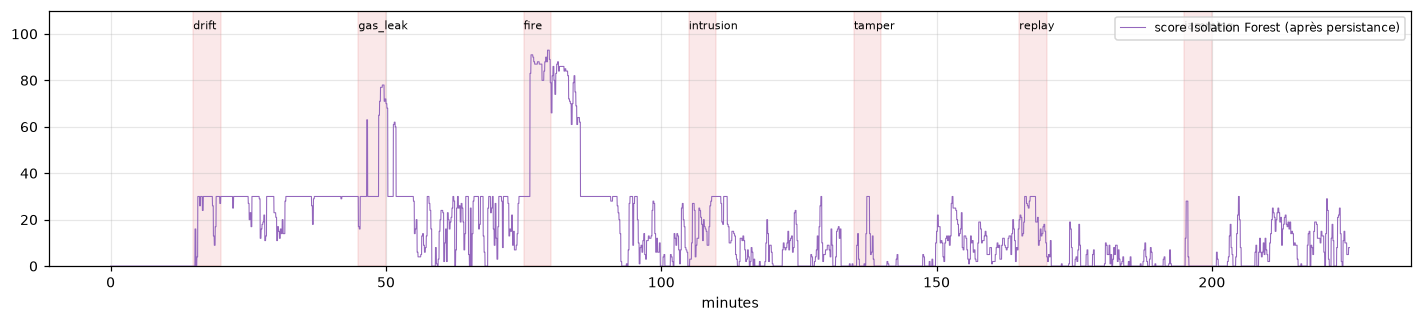

In [11]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(tr.t / 60, tr.iforest, lw=.7, color="tab:purple", label="score Isolation Forest (après persistance)")
for s in SCEN:
    ax.axvspan(START[s] / 60, END[s] / 60, color="tab:red", alpha=.1)
    ax.text(START[s] / 60, 102, s, fontsize=7)
ax.set_ylim(0, 110); ax.set_xlabel("minutes"); ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
print("score IF maximal par scénario :",
      {s: int(tr[(tr.t >= START[s]) & (tr.t <= END[s] + 120)].iforest.max()) for s in SCEN})

## 9. Fusion : trois domaines, un Sentinel Score, des incidents expliqués

`score = max(domaines) + 0,15 × (somme des autres)`. Les règles de corrélation transforment les signaux en incidents
nommés (`docs/architecture.md`). Un incident ouvert absorbe ses suites (pas de rafale d'alertes) et ne monte que si la
situation s'aggrave (fuite → incendie). Il se clôt après `cooldown_s` de calme **observé**.

Après une fuite ou un feu, le score redescend lentement (plateau à 70) : le gaz et la température mettent plus de
10 min à revenir à leur ligne de base. Ce n'est pas une nouvelle alerte, c'est l'état réel de la pièce.

{
 "device_id": "esp-01",
 "source": "brain",
 "domain": "environment",
 "type": "gas_leak",
 "severity": "warning",
 "score": 71,
 "eta_min": 7.3,
 "ts": 1790002736,
 "explanation": "Gaz +7 % au-dessus de la ligne de base (ratio 1,07), montée de +10 %/min (maximum sain 10 %/min), température stable (22 °C) ; ratio gaz critique (1,8) prévu dans 7,3 min",
 "factors": [
  {
   "name": "eta_min",
   "value": 7.3,
   "contribution": 0.44
  },
  {
   "name": "gas_ratio",
   "value": 1.075,
   "contribution": 0.37
  },
  {
   "name": "iforest",
   "value": 51,
   "contribution": 0.19
  }
 ],
 "details": {
  "retrospective": false,
  "rx_ts": 1790002736.0,
  "buffered_received": 0
 }
}


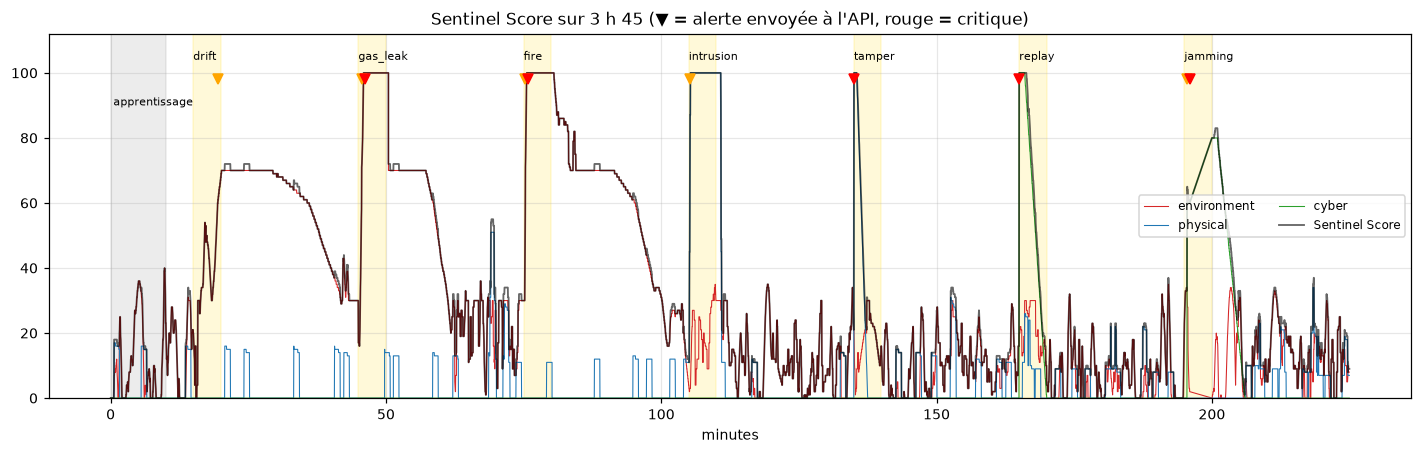

In [12]:
fig, ax = plt.subplots(figsize=(13, 4.2))
for col, c in (("environment", "tab:red"), ("physical", "tab:blue"), ("cyber", "tab:green")):
    ax.plot(tr.t / 60, tr[col], lw=.7, color=c, label=col)
ax.plot(tr.t / 60, tr.score, lw=1.2, color="k", alpha=.6, label="Sentinel Score")
for s in SCEN:
    ax.axvspan(START[s] / 60, END[s] / 60, color="gold", alpha=.15)
    ax.text(START[s] / 60, 104, s, fontsize=7)
for _, a in al.iterrows():
    ax.plot(a.t / 60, 98, "v", color={"critical": "red", "warning": "orange", "info": "grey"}[a.severity], ms=7)
ax.axvspan(0, 10, color="grey", alpha=.15); ax.text(.5, 90, "apprentissage", fontsize=7)
ax.set_ylim(0, 112); ax.set_xlabel("minutes"); ax.legend(loc="center right", fontsize=8, ncol=2)
ax.set_title("Sentinel Score sur 3 h 45 (▼ = alerte envoyée à l'API, rouge = critique)"); fig.tight_layout()
print(json.dumps({k: v for k, v in alerts[1].items() if k not in ("rx_t", "scénario")}, ensure_ascii=False, indent=1))

## 10. Évaluation

**Avance** = instant du premier seuil brut du profil (ratio gaz 1,3 ou 35 °C) − instant de la première alerte Brain.
Pour les scénarios sans grandeur physique (intrusion, effraction, rejeu, brouillage), on mesure le délai de détection.

In [13]:
EXPECTED = {"drift": ["thermal_drift", "fire_risk"], "gas_leak": ["gas_leak", "fire_risk"],
            "fire": ["fire_risk", "gas_leak"], "intrusion": ["intrusion_suspected"], "tamper": ["sabotage"],
            "replay": ["cyber_attack"], "jamming": ["jamming_suspected"]}
rows, fc_rows = [], []
for s, types in EXPECTED.items():
    d0, a = first_alert(s, types)
    raws = [r for r in (raw_cross(s, "gas_ratio", 1.3), raw_cross(s, "temp_c", 35)) if r is not None]
    raw = min(raws) if raws else None
    win = al[(al.t >= START[s] - 5) & (al.t <= END[s] + 600)]
    rows.append({"scénario": s, "alertes (dans l'ordre)": " → ".join(f"{x.type} ({x.severity})" for x in
                                                                    win.itertuples()),
                 "délai Brain (s)": d0, "seuil brut gaz/temp (s)": raw if raw is not None else "jamais",
                 "avance (s)": (raw - d0) if (raw is not None and d0 is not None) else
                 ("aucun seuil brut" if d0 is not None else None)})
    crit = raw_cross(s, "gas_ratio", 1.8)
    for x in win[win.eta_min.notna()].itertuples():
        fc_rows.append({"scénario": s, "alerte": f"{x.type} ({x.severity})", "à (s)": int(x.t - START[s]),
                        "eta annoncé (min)": x.eta_min, "réel (min)": round((crit - (x.t - START[s])) / 60, 1),
                        "avance sur le seuil critique (s)": int(crit - (x.t - START[s]))})
evaluation = pd.DataFrame(rows)
display(evaluation)
display(pd.DataFrame(fc_rows))
fp = al[al.scénario == "normal"]
print(f"Alertes pendant le régime normal du jeu d'évaluation ({(cap.label == 'normal').sum() * 2 / 3600:.1f} h, "
      f"hors apprentissage) : {len(fp)}")

,scénario,alertes (dans l'ordre),délai Brain (s),seuil brut gaz/temp (s),avance (s)
0,drift,thermal_drift (warning),268,jamais,aucun seuil brut
1,gas_leak,gas_leak (warning) → gas_leak (critical),36,95,59
2,fire,gas_leak (warning) → fire_risk (critical),20,96,76
3,intrusion,intrusion_suspected (warning),12,jamais,aucun seuil brut
4,tamper,sabotage (critical),0,jamais,aucun seuil brut
5,replay,cyber_attack (critical),0,jamais,aucun seuil brut
6,jamming,jamming_suspected (warning) → jamming_suspecte...,30,jamais,aucun seuil brut


,scénario,alerte,à (s),eta annoncé (min),réel (min),avance sur le seuil critique (s)
0,gas_leak,gas_leak (warning),36,7.3,3.5,207
1,gas_leak,gas_leak (critical),76,3.0,2.8,167
2,fire,gas_leak (warning),20,7.2,3.6,219
3,fire,fire_risk (critical),50,3.1,3.1,189


Alertes pendant le régime normal du jeu d'évaluation (2.0 h, hors apprentissage) : 0


In [14]:
# Fausses alarmes sur 24 h normales JAMAIS vues (graine 123) : ~1 min 30 de calcul
simulate("normal_24h_test", "--scenario", "normal", "--duration", "86400", "--seed", "123")
b2, fps = SentinelBrain(BrainConfig()), []
for line in open(DATA / "normal_24h_test_rx.jsonl", encoding="utf-8"):
    m = json.loads(line)
    fps += [o["payload"] for o in b2.handle(m["topic"], m["payload"], m["rx_ts"]) if o["kind"] == "alert"]
fpd = pd.DataFrame(fps)
print(f"24 h normales inédites : {len(fpd)} alerte(s), dont critiques : {0 if fpd.empty else (fpd.severity == 'critical').sum()}")
fpd[["ts", "type", "severity", "score", "explanation"]] if len(fpd) else None

généré : normal_24h_test


24 h normales inédites : 1 alerte(s), dont critiques : 0


,ts,type,severity,score,explanation
0,1790070080,jamming_suspected,warning,60,Signal Wi-Fi en chute (RSSI -66 dBm contre -55...


## 11. Bilan, limites et suite

**Ce que montre ce prototype**

- **Fuite de gaz** : alerte **1 minute avant** le seuil brut de 1,3 (36 s contre 95 s), déjà avec `eta_min` ;
  passage en *critique* à 76 s avec « critique dans 3,0 min » : le seuil de 1,8 est franchi 2 min 47 plus tard
  (erreur de prévision : 13 s). Le critère de la tâche est rempli.
- **Incendie** : vu à 20 s comme une montée de gaz, requalifié **risque incendie critique** 30 s plus tard dès que
  la température monte, avec une prévision juste à quelques secondes près.
- La **première** prévision est trop optimiste (7 min au lieu de 3,5) : la tendance est encore en train de
  s'établir. Elle se corrige en 40 s ; c'est pourquoi la gravité *critique* attend `eta ≤ 3 min`.
- **Dérive lente** (climatisation) : détectée alors qu'**aucun seuil brut ne se déclenche jamais** (25 °C < 35 °C).
- **Intrusion, effraction, rejeu, brouillage** : détectés, chacun expliqué en une phrase, avec la bonne gravité.
- **Fausses alarmes** : aucune sur le régime normal du jeu d'évaluation ; sur 24 h inédites, voir la cellule
  précédente (aucune critique).
- **Coût** : une à deux millisecondes par message sur un poste ; le boîtier n'en envoie qu'un toutes les 2 s.

**Limites, à dire honnêtement au jury**

- Données **simulées** : les réglages (`CALIBRATION`) devront être refaits sur des heures de mesures réelles
  (section 3, même code). Le MQ-2 réel dérive avec l'humidité et la température : la ligne de base EWMA le suit.
- Le DHT11 (pas de 1 °C) rend la dérive lente détectable après environ 4 min seulement : c'est la limite du capteur.
- Le RSSI n'arrive qu'avec la santé (toutes les 30 s) : le brouillage est vu en 30 à 60 s.
- L'Isolation Forest a besoin de 15 min de régime sain pour son premier modèle ; sur ces scénarios il confirme
  (incendie) plus qu'il n'anticipe.
- Le brouillage seul (RSSI qui baisse, sans coupure) donne au plus un *avertissement* : 1 sur 24 h normales inédites.

**Suite** : le service `ai/anomaly/app/main.py` (tâche je3) branche ce même moteur sur le broker et l'API, et le
fusionne avec la vision (`ai/vision`) : intrusion confirmée par le PIR, badges et horaires, sabotage de la caméra.